# Module 1: Droplet Flight

This module started as a generic computational physics assignment: simulate a
spherical liquid droplet falling through air under gravity and aerodynamic drag.
The original used Stokes drag (F = 3*pi*mu*d*v), which is only valid for Re << 1,
and ran the integrator for a fixed time span with no event detection.

Three things were changed for inkjet:

1. Replaced Stokes drag with the Schiller-Naumann correlation, which is valid
   up to Re ~ 800. Inkjet drops (d ~ 20-80 um, v ~ 5-15 m/s) run at Re ~ 10-100,
   well outside the Stokes regime.
2. Added event-based termination so integration stops when the droplet hits the
   substrate instead of running for a fixed time.
3. Added a Monte Carlo placement error simulation to model nozzle-to-nozzle
   velocity and angle variation.

The underlying physics (Newton's 2nd law, ODE integration with RK45) is unchanged.


In [1]:
import sys
from pathlib import Path

# Walk up from current directory until we find the project root
# (the folder that contains src/). Works regardless of where
# Cursor or Jupyter launches from.
_search = Path.cwd()
while _search != _search.parent:
    if (_search / 'src').exists():
        break
    _search = _search.parent

ROOT    = _search
SRC     = ROOT / 'src'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f'ROOT   : {ROOT}')
print(f'SRC    : {SRC}')
print(f'FIGURES: {FIGURES}')

import numpy as np
import matplotlib.pyplot as plt
from ink_properties import INKS, SUBSTRATES
from flight import simulate_flight, placement_error_distribution, drag_coefficient, plot_trajectory, plot_placement_error

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print(f'src    : {SRC}')
print(f'figures: {FIGURES}')

ROOT   : c:\
SRC    : c:\src
FIGURES: c:\results\figures
src    : c:\src
figures: c:\results\figures


## 1.1 Single trajectory

Simulate one droplet ejected straight down (90 deg) at 8 m/s from a 1 mm standoff height.

Landing position : x = 0.0 um from nozzle
Impact velocity  : v = 7.314 m/s
Reynolds at impact: Re = 28.8


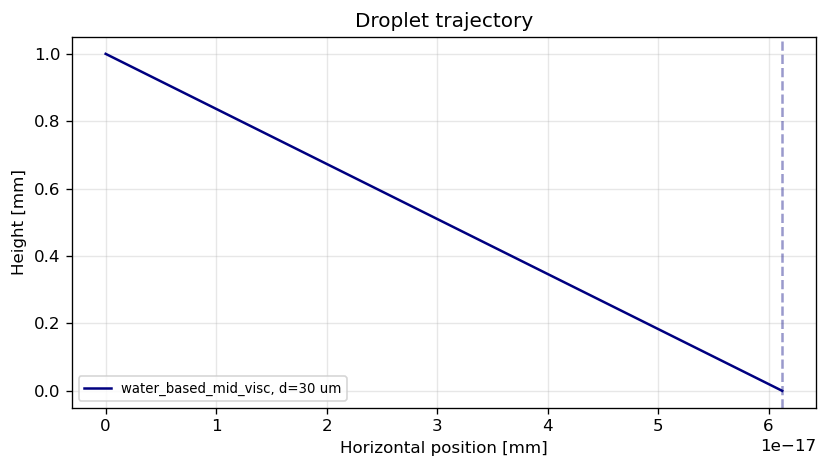

In [2]:
ink = INKS['water_based_mid_visc']
d   = 30e-6

result = simulate_flight(ink, d=d, v0=8.0, angle_deg=90.0, y0=1e-3)

print(f"Landing position : x = {result['x_land']*1e6:.1f} um from nozzle")
print(f"Impact velocity  : v = {result['v_impact']:.3f} m/s")
print(f"Reynolds at impact: Re = {result['Re_impact']:.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
plot_trajectory(result, ink, d, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '01_trajectory.png', bbox_inches='tight')
plt.show()

## 1.2 Effect of jetting angle

In a real printhead, nozzles are not perfectly perpendicular to the substrate.
Small angular deviations shift the landing position.

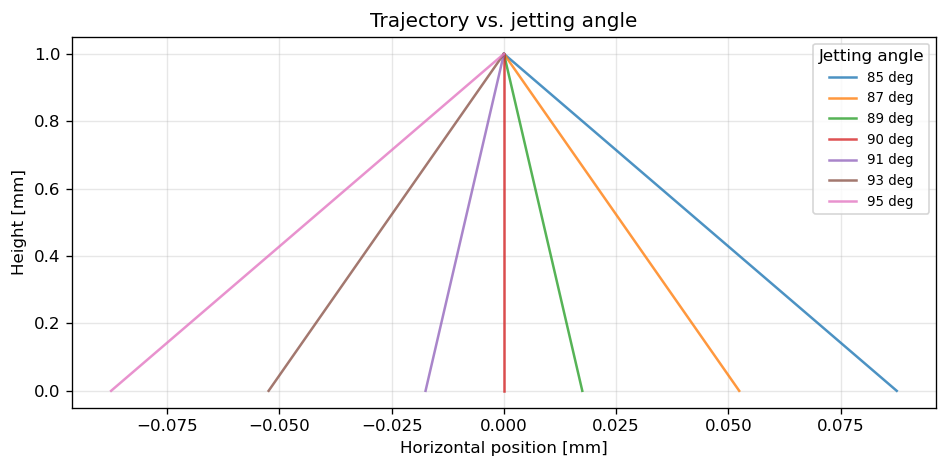

In [3]:
angles = [85, 87, 89, 90, 91, 93, 95]
fig, ax = plt.subplots(figsize=(8, 4))

for angle in angles:
    r = simulate_flight(ink, d=d, v0=8.0, angle_deg=angle, y0=1e-3)
    ax.plot(r['x']*1e3, r['y']*1e3, label=f'{angle} deg', alpha=0.8)

ax.set_xlabel('Horizontal position [mm]')
ax.set_ylabel('Height [mm]')
ax.set_title('Trajectory vs. jetting angle')
ax.legend(fontsize=8, title='Jetting angle')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '01_angle_sweep.png', bbox_inches='tight')
plt.show()

## 1.3 Schiller-Naumann vs. Stokes drag

This is the main change from the original assignment. At Re ~ 50 (typical for inkjet),
Stokes drag underestimates the drag coefficient by about 30%, which would give the
wrong impact velocity and landing position.

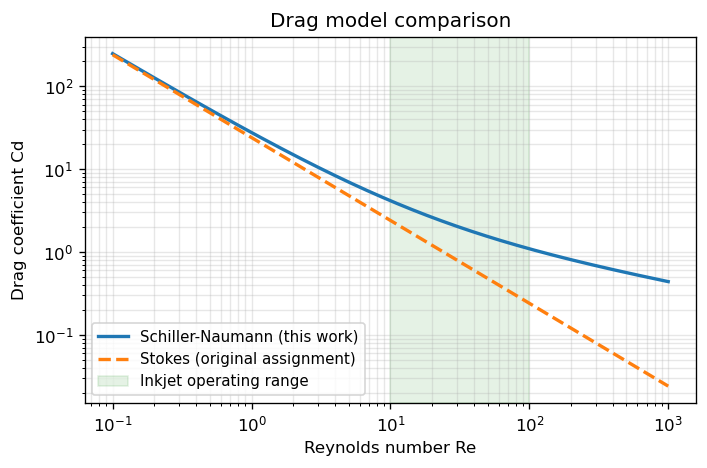

In [4]:
Re_range  = np.logspace(-1, 3, 300)
Cd_SN     = [drag_coefficient(Re) for Re in Re_range]
Cd_Stokes = 24.0 / Re_range

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(Re_range, Cd_SN,     label='Schiller-Naumann (this work)', linewidth=2)
ax.loglog(Re_range, Cd_Stokes, label='Stokes (original assignment)', linestyle='--', linewidth=2)
ax.axvspan(10, 100, alpha=0.1, color='green', label='Inkjet operating range')
ax.set_xlabel('Reynolds number Re')
ax.set_ylabel('Drag coefficient Cd')
ax.set_title('Drag model comparison')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '01_drag_comparison.png', bbox_inches='tight')
plt.show()

## 1.4 Monte Carlo dot placement error

Real printheads have nozzle-to-nozzle variation in jetting velocity (typically 1-3% CV)
and angle (typically +/- 0.5 deg). This produces a spread of landing positions.
The standard deviation of that spread is the dot placement error.

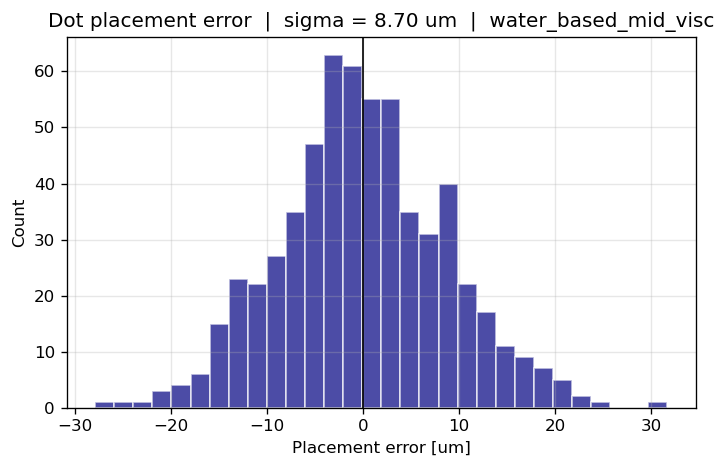

Placement error sigma = 8.70 um
Typical inkjet spec: sigma < 10 um


In [5]:
x_lands = placement_error_distribution(
    ink, d=d,
    v0_mean=8.0, v0_std=0.16,
    angle_mean_deg=90.0, angle_std_deg=0.5,
    n_drops=600,
)

fig, ax = plt.subplots(figsize=(6, 4))
plot_placement_error(x_lands, ink, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '01_placement_error.png', bbox_inches='tight')
plt.show()

sigma_um = np.nanstd((x_lands - np.nanmean(x_lands)) * 1e6)
print(f"Placement error sigma = {sigma_um:.2f} um")
print(f"Typical inkjet spec: sigma < 10 um")